### Conditional Graph
- Implement conditional logic to route the flow for data to different nodes.

- Create a route node to handle the decission maming and control the graph flow.

- Use START and END nodes to manage Entry and Exit

- learn add_conditional_edges()

In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [2]:
# Define the State Schema
class AgentState(TypedDict):
    number1: int
    operation: str
    number2: int
    final_number: int

In [3]:
# Define the node functions
def adder(state: AgentState) -> AgentState:
    state['final_number'] = state['number1'] + state['number2']
    return state

def substracter(state: AgentState) -> AgentState:
    state['final_number'] = state['number1'] - state['number2']
    return state

# Note, it does not return any state.
def decide_next_node(state: AgentState) -> AgentState:
    if state['operation'] == "+":
        return "addition_operation"
    else:
        return "substraction_operation"

In [4]:
# Build the graph
graph = StateGraph(AgentState)

graph.add_node("add_node", adder)
graph.add_node("subtract_node", substracter)
#router node makes the change, does not change the state. 
graph.add_node("router", lambda state: state) #passthrough function

graph.add_edge(START, "router")
graph.add_conditional_edges(
    source="router",
    path=decide_next_node, # Deciding Action Returns the key to path_map
    path_map={
        # Edge: Node
        "addition_operation": "add_node",
        "substraction_operation": "subtract_node"
    }
)

graph.add_edge("add_node", END)
graph.add_edge("subtract_node", END)

app = graph.compile()


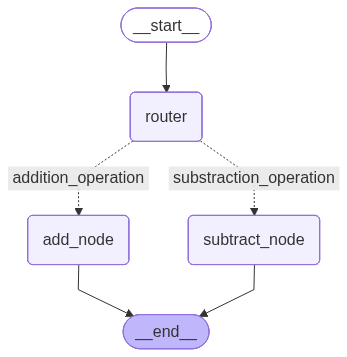

In [5]:
# Display the graph in Jupyter Notebook
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [6]:
result = app.invoke({"number1": 4, "number2": 5, "operation": "+"})
print(result['final_number'])

9
